In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('1-studyhours.csv')

In [3]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


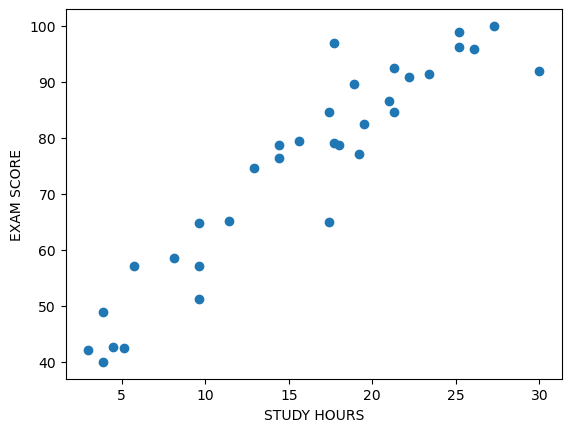

In [4]:
plt.scatter(data = df , x = 'Study Hours' , y = 'Exam Score') 
# Genel bir kural olarak üzerine tahmin yapilacak olan deger y eksenine yazilir(Exam Score)
plt.xlabel('STUDY HOURS')
plt.ylabel('EXAM SCORE')
plt.show()

In [5]:
X = df[['Study Hours']] # Girdiler genelde birden fazla olduğu icin python bunun DataFrame tarzında([[Seklinde]])verilmesini ister
# Bundan dolayı biz x yani girdi verirken DataFrame tarzında veririz

In [6]:
y = df['Exam Score'] 
# y degeri de bizim verdiğimiz girdler sonucunda ulaşılacak sonuc veya yapılacak tahmin parametresi oldugu için 1 tanedir bundan 
# dolayı Series türünde olması beklenir ve bu şekilde kullanılır 

In [7]:
type(X)

pandas.core.frame.DataFrame

In [8]:
type(y)

pandas.core.series.Series

# TRAIN - TEST SPLIT

In [9]:
# Dataset bölünür bir kısmı ile model eğitilir kalan kısımı ile de modelin eğitim sonucu yaptığı tahminlerin 
# datasette bulunan gercek degerden ne kadar farklı veya ne kadar isabetli tahminler yaptığı bulunur

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# train_test_split() adlı fonksiyon 4 tane DataFrame deger geriye dondürür(Sırası Onemli) 
# X_train , X_test , y_train , y_test

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 10 ) 

In [13]:
# Test_size Datasetten test edilmek icin cekilecek verinin miktarını belirtiriz 0 - 1 arasi deger alir

In [14]:
# Random state kullanılma sebebi = Tekrar Edilebilirlik (Reproducibility):
# Aynı random_state değeri verildiğinde, kodu her çalıştırdığında aynı eğitim ve test setleri oluşur. 
# Setin nereden boluneceğini belirtmek gibi
# Böylece sonuçların tutarlılığını sağlarsın.

In [15]:
X_train

,Study Hours
1,9.6
20,3.9
14,21.0
19,21.3
6,19.2
11,26.1
31,25.2
18,17.4
26,9.6
30,23.4


In [16]:
X_test

,Study Hours
21,8.1
7,22.2
5,18.0
2,4.5
3,11.4
22,14.4
13,27.3
24,9.6
12,30.0


In [17]:
y_train

1     57.1
20    49.0
14    86.6
19    84.7
6     77.1
11    95.9
31    96.2
18    64.9
26    64.8
30    91.5
23    42.2
10    92.4
28    79.1
32    89.6
8     99.0
27    79.5
16    57.2
25    42.4
17    74.7
0     40.0
15    97.0
4     78.7
29    82.4
9     84.6
Name: Exam Score, dtype: float64

In [18]:
y_test

21     58.5
7      90.8
5      78.8
2      42.7
3      65.1
22     76.5
13    100.0
24     51.2
12     92.0
Name: Exam Score, dtype: float64

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [21]:
X_train.head()

,Study Hours
1,9.6
20,3.9
14,21.0
19,21.3
6,19.2


In [22]:
X_train.tail()

,Study Hours
0,3.9
15,17.7
4,14.4
29,19.5
9,17.4


In [23]:
X_train = scaler.fit_transform(X_train) # Değerleri normalize ederek -1 ve 1 arası degerler vermeye çalılışıyor
# z = (x - u) / s Formüldeki degerler neticesinde bir hesaplma işlemi yapılıyor . u ve s değerleri fit ile hesaplanıyor transform 
# transform ile islem yapılıyor 

In [24]:
X_test = scaler.transform(X_test) # test kısımı X_train ' de kullandığımız u ve s degerlerini kullanrak formulu uygular bunun sebebi 
# Eğitilecek modelin X_test hakkında bilgi sahibi olmasını engellemek ve veri sızmasının önüne geçmek

In [25]:
X_train

array([[-0.84317807],
       [-1.64087351],
       [ 0.7522128 ],
       [ 0.79419677],
       [ 0.50030898],
       [ 1.4659403 ],
       [ 1.33998839],
       [ 0.24840516],
       [-0.84317807],
       [ 1.08808457],
       [-1.76682542],
       [ 0.79419677],
       [ 0.29038913],
       [ 0.45832501],
       [ 1.33998839],
       [-0.00349866],
       [-1.38896969],
       [-1.47293763],
       [-0.3813544 ],
       [-1.64087351],
       [ 0.29038913],
       [-0.17143455],
       [ 0.54229295],
       [ 0.24840516]])

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
regression = LinearRegression()

In [28]:
regression.fit(X_train , y_train)

LinearRegression()

In [29]:
print('Coefficient : ', regression.coef_)
print('Intercept : ' , regression.intercept_)

Coefficient :  [17.19007429]
Intercept :  75.27499999999999


In [30]:
# MATEMATIKSEL FORMUL ASLINDA -- >> 75.2 + 17.1 X 'miş

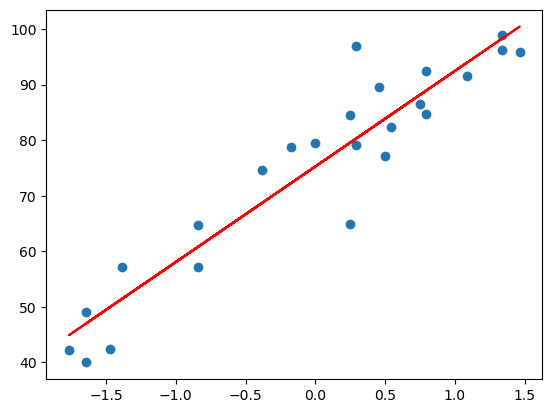

In [31]:
plt.scatter(x = X_train , y = y_train) # Asıl karşılaştırma tablosu çizilir
plt.plot(X_train , regression.predict(X_train) , 'r') # Best fit line'ı verir
plt.show()

In [32]:
# Tahminler yapma 

In [33]:
regression.predict([[20]]) # 20 saat çalışan birinin kaç alacağını bulmaya çalışıyorum ama çalılma saaatleri yani X_train datalar 
# transform edildi ve -1 ile 1 arasında bir yere geldi

array([419.07648587])

In [34]:
regression.predict(scaler.transform([[20]]))

C:\Users\MSI-NB\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([85.79990207])

In [35]:
regression.predict(scaler.transform([[3]]))

C:\Users\MSI-NB\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([44.90313973])

In [36]:
# prediction with test data

In [37]:
y_pred_test = regression.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 

In [39]:
mae = mean_absolute_error(y_test , y_pred_test)
mse = mean_squared_error(y_test , y_pred_test)
rmse = np.sqrt(mse)

print('mse : ' , mse) # Model tahmini ile gerçek değerler arası hatanın karesidir outlier dataya karşı az dayanıklıdır
print('mae : ' , mae) # Model tahmini ile gerçek değerler arasındaki ortalama farktır outlier dataya karşı dayanıklıdır
print('rmse : ' , rmse)
# Bunlar biribiriytle karşılaştırmak icin uygundur ama en iyi anlam katan r2 ve adjusted r2 score'dır

mse :  53.308299018972555
mae :  4.9558173694840555
rmse :  7.301253249886115


In [40]:
r2 = r2_score(y_test , y_pred_test)
print('r2 score : ' , r2) # %84 doğruluk payı var pek de iyi değil

r2 score :  0.8461522048142492


In [41]:
# Adjusted r2 score : 

1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)



0.8241739483591419